In [756]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
import math

# 1 

In [757]:
m = 10
A =8 

g = lambda A,i: (A**i)/math.factorial(i) 

M_array = np.arange(0,m+1,dtype=int)
g_correct = np.zeros_like(M_array,dtype=float)
for i in range(m+1):
    g_correct[i] = g(A,M_array[i])

p_target = g_correct/np.sum(g_correct)

In [758]:
N = 10_000
m = 10
A =8 

X = np.zeros(N+1,dtype=int)
X[0] = 1
for i in range(N):
    Y = np.random.randint(0,m+1)
    ratio = g(A,Y)/g(A,X[i])
    alpha =  min(1, ratio)
    if np.random.rand() < alpha:
        X[i+1] = Y
    else: X[i+1] = X[i]

In [759]:
counts = np.bincount(X[1000::10], minlength=m)  
preditic_prob = counts/np.sum(counts)
expected = p_target * np.sum(counts)

#plt.bar(np.arange(m+1), counts)  
#plt.bar(np.arange(m+1), expected, alpha=0.5)       
# m = 9

In [760]:
chi = np.sum((counts-expected)**2 / expected)
p = 1- ss.chi2.cdf(chi,df = 10)
ss.chisquare(counts,expected,ddof=0)

Power_divergenceResult(statistic=np.float64(7.823840310612691), pvalue=np.float64(0.646039190991992))

In [761]:

def something():
    N = 10_000
    m = 10
    A =8 

    X = np.zeros(N+1,dtype=int)
    X[0] = 1
    for i in range(N):
        Y = np.random.randint(0,m+1)
        ratio = g(A,Y)/g(A,X[i])
        alpha =  min(1, ratio)
        if np.random.rand() < alpha:
            X[i+1] = Y
        else: X[i+1] = X[i]
    return X

p_target = g_correct / g_correct.sum()
mask = p_target.flatten() > 0

pvals = []

for _ in range(2000):
    samples = something()
    counts = np.bincount(samples[1000::10], minlength=m)  
    preditic_prob = counts/np.sum(counts)
    expected = p_target * np.sum(counts)
    _, p = ss.chisquare(counts, expected)
    pvals.append(p)

Text(0, 0.5, 'count')

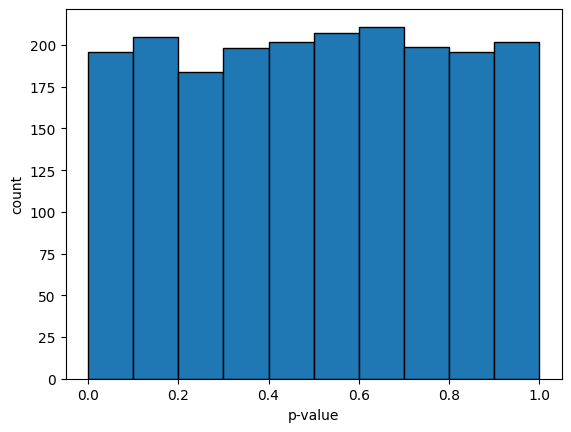

In [762]:
pvals = np.array(pvals)
plt.hist(pvals, bins=10, range=(0,1), edgecolor='k')
plt.xlabel('p-value'); plt.ylabel('count')

# 2

In [763]:
import numpy as np, math

N = 10_000
m = 10
A1 = 4
A2 = 4

g = lambda A1, A2, i, j: (A1**i)/math.factorial(i) * (A2**j)/math.factorial(j)

X = np.zeros((N+1, 2), dtype=int)      
X[0] = [0, 0]

for i in range(N):
    Y1 = np.random.randint(0, m+1)
    Y2 = np.random.randint(0, m+1)
    while Y1 + Y2 > m:                 
        Y1 = np.random.randint(0, m+1)
        Y2 = np.random.randint(0, m+1)

    ci, cj = X[i]                     
    ratio = g(A1, A2, Y1, Y2) / g(A1, A2, ci, cj)
    if np.random.rand() < min(1, ratio):
        X[i+1] = [Y1, Y2]
    else:
        X[i+1] = X[i]


M_array = np.arange(0,m+1,dtype=int)
g_correct = np.zeros((m+1,m+1),dtype=float)
for i in range(m+1):
    for j in range(m+1):
        if j+i <= m:
            g_correct[i][j] = g(A1,A2,M_array[i],M_array[j])
        else: continue


In [764]:
count = np.zeros((m+1, m+1))
for ci, cj in X[1000::10]:      
    count[ci][cj] += 1   

p_target = g_correct / np.sum(g_correct)  

mask = p_target.flatten() > 0
obs = count.flatten()[mask]
exp = p_target.flatten()[mask] * obs.sum()

chi, p_normal = ss.chisquare(obs, exp)
p_normal

np.float64(0.8726654245552008)

In [784]:
def something_1():
    
    N = 10_000
    m = 10
    A1 = 4
    A2 = 4

    g = lambda A1, A2, i, j: (A1**i)/math.factorial(i) * (A2**j)/math.factorial(j)

    X = np.zeros((N+1, 2), dtype=int)      
    X[0] = [0, 0]

    for i in range(N):
        Y1 = np.random.randint(0, m+1)
        Y2 = np.random.randint(0, m+1)
        while Y1 + Y2 > m:                 
            Y1 = np.random.randint(0, m+1)
            Y2 = np.random.randint(0, m+1)

        ci, cj = X[i]                     
        ratio = g(A1, A2, Y1, Y2) / g(A1, A2, ci, cj)
        if np.random.rand() < min(1, ratio):
            X[i+1] = [Y1, Y2]
        else:
            X[i+1] = X[i]
    return X




pvals = []

for _ in range(2000):
    samples = something_1()
    count = np.zeros((m+1, m+1))
    for ci, cj in samples[1000::10]:      
        count[ci][cj] += 1   

    p_target = g_correct / np.sum(g_correct)  

    mask = p_target.flatten() > 0
    obs = count.flatten()[mask]
    exp = p_target.flatten()[mask] * obs.sum()

    chi, p_coor = ss.chisquare(obs, exp)
    pvals.append(p_coor)

# cordinatwise

In [776]:

m = 10
A1 = 4
A2 = 4

g = lambda A1, A2, i, j: (A1**i)/math.factorial(i) * (A2**j)/math.factorial(j)

X = np.zeros((N+1, 2), dtype=int)      
X[0] = [0, 0]

for i in range(N):
    ci, cj = X[i]

    Y1 = np.random.randint(0, m - cj + 1)
    ratio = g(A1, A2, Y1, cj) / g(A1, A2, ci, cj)
    if np.random.rand() < min(1, ratio):
        ci = Y1

    Y2 = np.random.randint(0, m - ci + 1)
    ratio = g(A1, A2, ci, Y2) / g(A1, A2, ci, cj)
    if np.random.rand() < min(1, ratio):
        cj = Y2
    X[i+1] = [ci, cj]


count = np.zeros((m+1, m+1))
for ci, cj in samples[1000::10]:      
    count[ci][cj] += 1   

p_target = g_correct / np.sum(g_correct)  

mask = p_target.flatten() > 0
obs = count.flatten()[mask]
exp = p_target.flatten()[mask] * obs.sum()

chi, p_coor = ss.chisquare(obs, exp)
p_coor

np.float64(0.5085005482659629)

In [777]:
def something_2():
    m = 10
    A1 = 4
    A2 = 4

    g = lambda A1, A2, i, j: (A1**i)/math.factorial(i) * (A2**j)/math.factorial(j)

    X = np.zeros((N+1, 2), dtype=int)      
    X[0] = [0, 0]

    for i in range(N):
        ci, cj = X[i]

        Y1 = np.random.randint(0, m - cj + 1)
        ratio = g(A1, A2, Y1, cj) / g(A1, A2, ci, cj)
        if np.random.rand() < min(1, ratio):
            ci = Y1

        Y2 = np.random.randint(0, m - ci + 1)
        ratio = g(A1, A2, ci, Y2) / g(A1, A2, ci, cj)
        if np.random.rand() < min(1, ratio):
            cj = Y2
        X[i+1] = [ci, cj]
    return X




pvals_coor = []

for _ in range(2000):
    samples = something_2()
    count = np.zeros((m+1, m+1))
    for ci, cj in samples[1000::10]:      
        count[ci][cj] += 1   

    p_target = g_correct / np.sum(g_correct)  

    mask = p_target.flatten() > 0
    obs = count.flatten()[mask]
    exp = p_target.flatten()[mask] * obs.sum()

    chi, p_coor = ss.chisquare(obs, exp)
    pvals_coor.append(p_coor)

# gibs

In [778]:

m = 10
A1 = 4
A2 = 4

X = np.zeros((N+1, 2), dtype=int)
X[0] = [0, 0]

for t in range(N):
    ci, cj = X[t]

    hi = m - cj
    w = np.array([A1**k / math.factorial(k) for k in range(hi+1)])
    w = w/w.sum()
    i = np.random.choice(hi+1, p=w)

    hi = m - i
    w = np.array([A2**k / math.factorial(k) for k in range(hi+1)])
    w = w/w.sum()
    j = np.random.choice(hi+1, p=w)

    X[t+1] = [i, j]

count = np.zeros((m+1, m+1))
for ci, cj in X[1000::10]:      
    count[ci][cj] += 1   

p_target = g_correct / np.sum(g_correct)  

mask = p_target.flatten() > 0
obs = count.flatten()[mask]
exp = p_target.flatten()[mask] * obs.sum()

chi, p_gibs = ss.chisquare(obs, exp)
p_gibs

np.float64(0.7861572121640842)

In [779]:
def something_3():
    N = 10_000
    m = 10
    A1 = 4
    A2 = 4

    X = np.zeros((N+1, 2), dtype=int)
    X[0] = [0, 0]

    for t in range(N):
        ci, cj = X[t]

        hi = m - cj
        w = np.array([A1**k / math.factorial(k) for k in range(hi+1)])
        w = w/w.sum()
        i = np.random.choice(hi+1, p=w)

        hi = m - i
        w = np.array([A2**k / math.factorial(k) for k in range(hi+1)])
        w = w/w.sum()
        j = np.random.choice(hi+1, p=w)

        X[t+1] = [i, j]
    return X


pvals_gibs = []

for _ in range(2000):
    samples = something_3()
    count = np.zeros((m+1, m+1))
    for ci, cj in samples[1000::10]:      
        count[ci][cj] += 1   

    p_target = g_correct / np.sum(g_correct)  

    mask = p_target.flatten() > 0
    obs = count.flatten()[mask]
    exp = p_target.flatten()[mask] * obs.sum()

    chi, p_gibs = ss.chisquare(obs, exp)
    pvals_gibs.append(p_gibs)

In [780]:
#pvals_gibs,pvals_coor,pvals # pvals = normal mh algorithm

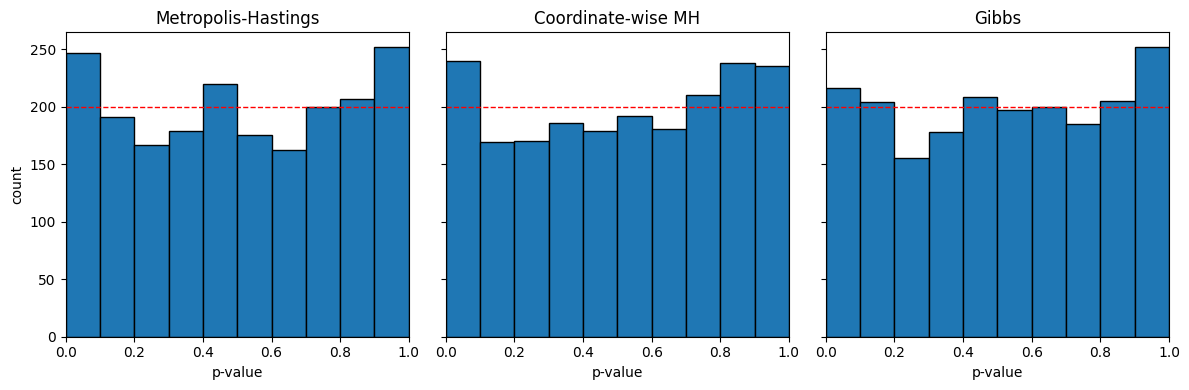

In [785]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

data = [pvals, pvals_coor, pvals_gibs]
titles = ['Metropolis-Hastings', 'Coordinate-wise MH', 'Gibbs']

bins = np.linspace(0, 1, 11)
for ax, p, t in zip(axes, data, titles):
    ax.hist(p, bins=bins, edgecolor='black')
    ax.axhline(len(p) / (len(bins) - 1), color='red', linestyle='--', linewidth=1)
    ax.set_title(t)
    ax.set_xlabel('p-value')
    ax.set_xlim(0, 1)

axes[0].set_ylabel('count')
fig.tight_layout()
fig.savefig('pval_hist.pdf', bbox_inches='tight')
plt.show()

# chi squared test